In [1]:
import os
import sys

module_path = os.path.abspath(os.path.join('..'))
sys.path.append(module_path)

In [2]:
from binning_process.compare import compare_methods

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [4]:
data = pd.read_csv(r"D:\Data\f88_bscore_v4\data\Data_Sets_15\20251030_Train_Data_15.csv")
data

,FlagTarget_B4+@9M,customer_code,cutoff_date,CUTOFF_MONTH_WID,min_trans_in_3month,min_trans_in_6month,ltv_max_closedloandtl,collateral_amt_latest,n_paidontime_in_3month,dpd_mean_in_9month,province_code_latest
0,0,16104509,20240331,202403,3857000.0,1036.0,2.250000,290.0,4.0,0.0,01
1,0,16104509,20240430,202404,1999.0,1999.0,2.250000,290.0,4.0,0.0,01
2,0,16104509,20240831,202408,1258.0,1258.0,2.250000,280.0,4.0,0.0,01
3,0,16177982,20240430,202404,7181465.0,7181465.0,14.305750,440.0,4.0,0.0,01
4,1,16216573,20240229,202402,5439179.0,5439179.0,1.431174,330.0,3.0,0.0,01
...,...,...,...,...,...,...,...,...,...,...,...
44742,0,202158016817,20240229,202402,6031726.0,6031726.0,10.066043,410.0,3.0,0.0,25
44743,0,202158241464,20240731,202407,5604057.0,5604057.0,2.878788,260.0,3.0,0.0,31
44744,0,202159861057,20240430,202404,11083452.0,9913704.0,6.308122,320.0,3.0,1.7,79
44745,0,202162178813,20240630,202406,1324772.0,654943.0,21.000000,380.0,4.0,0.0,48


In [5]:
X = data.drop('FlagTarget_B4+@9M', axis = 1)
y = data['FlagTarget_B4+@9M']

In [6]:
y.value_counts(normalize=True)

FlagTarget_B4+@9M
0    0.957137
1    0.042863
Name: proportion, dtype: float64

In [7]:
X['min_trans_in_3month']

0         3857000.0
1            1999.0
2            1258.0
3         7181465.0
4         5439179.0
            ...    
44742     6031726.0
44743     5604057.0
44744    11083452.0
44745     1324772.0
44746     6000752.0
Name: min_trans_in_3month, Length: 44747, dtype: float64

In [8]:
feature_name = 'min_trans_in_6month'
val = X[feature_name]
max_bins = 20
n_init_bins = 50
max_depth = 3
result, methods = compare_methods(
    x=val, y=y,
    feature_name=feature_name,
    max_bins=max_bins,
    n_init_bins=n_init_bins,
    max_depth=max_depth,
    special_values=[-1],
)

# # ── Transform sang WOE ────────────────────────────────────────────────
# woe_vals = b1.transform(val)
# print(f"\nWOE values (sample):\n{woe_vals.dropna().head(10).values}")

# # ── Plot ──────────────────────────────────────────────────────────────
# fig1 = b1.plot()
# plt.savefig("plot_isotonic.png", dpi=120, bbox_inches="tight")
# print("\nĐã lưu: plot_isotonic.png")
# plt.show()

20 50 3

  SO SÁNH METHODS — Feature: [min_trans_in_6month]
           Method      Group     IV  n_bins Monotonic  Direction  IV_Rating
         Isotonic supervised 0.1742       5         ✓ descending Trung bình
     DecisionTree supervised 0.1741       3         ✓ descending Trung bình
QuantileMonotonic supervised 0.1723       5         ✓ descending Trung bình
         ChiMerge supervised 0.1719       4         ✓ descending Trung bình
             MDLP supervised 0.1636       2         ✓ descending Trung bình



QuantileMonotonic


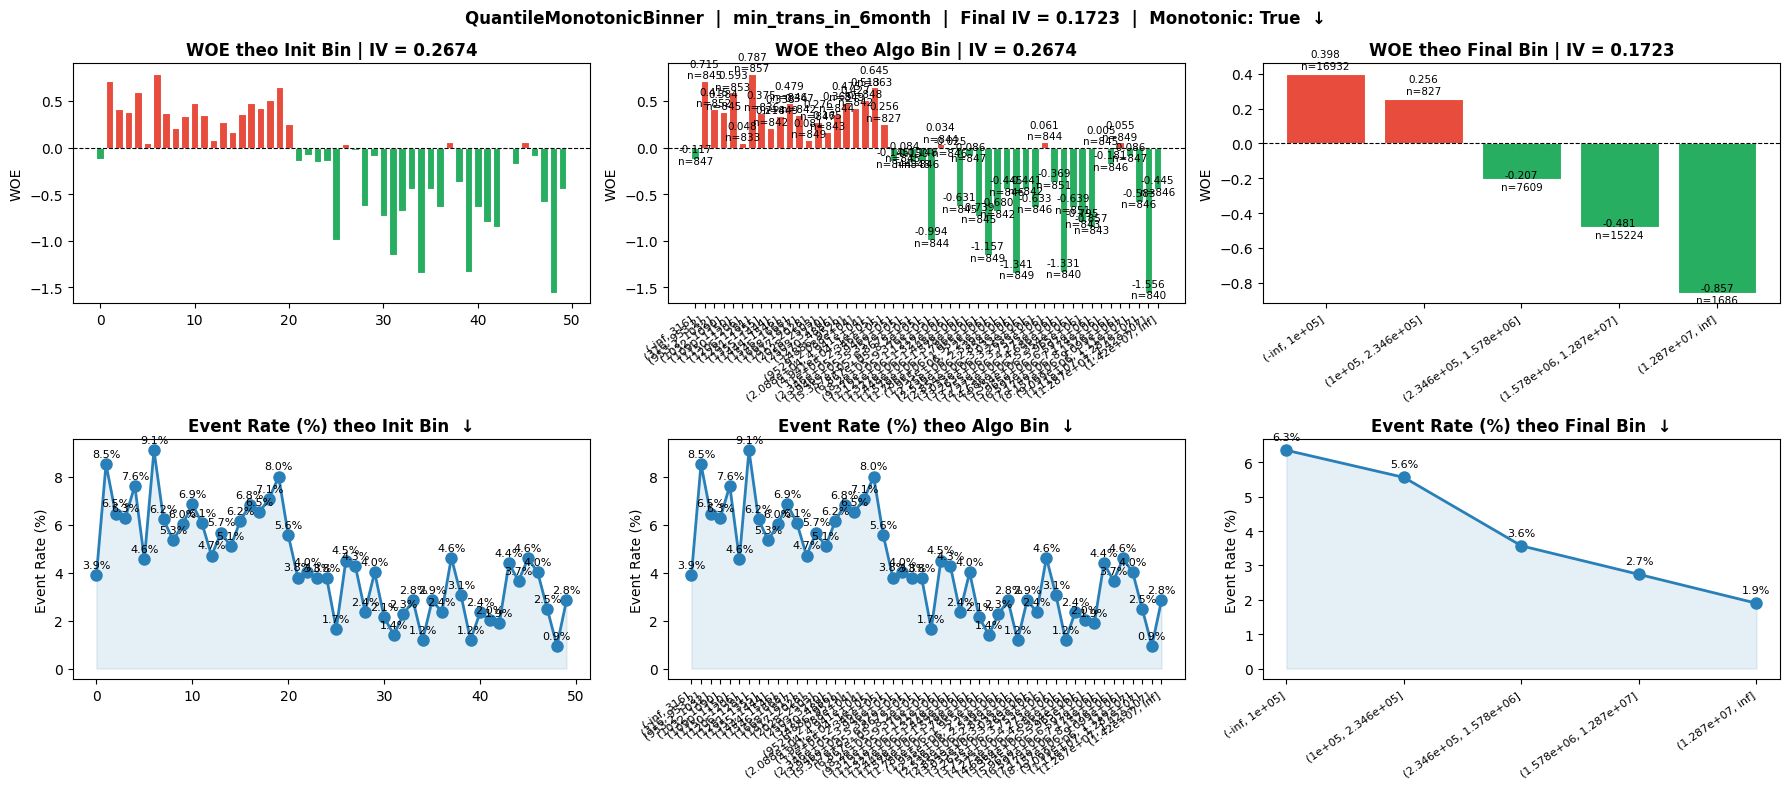

Isotonic


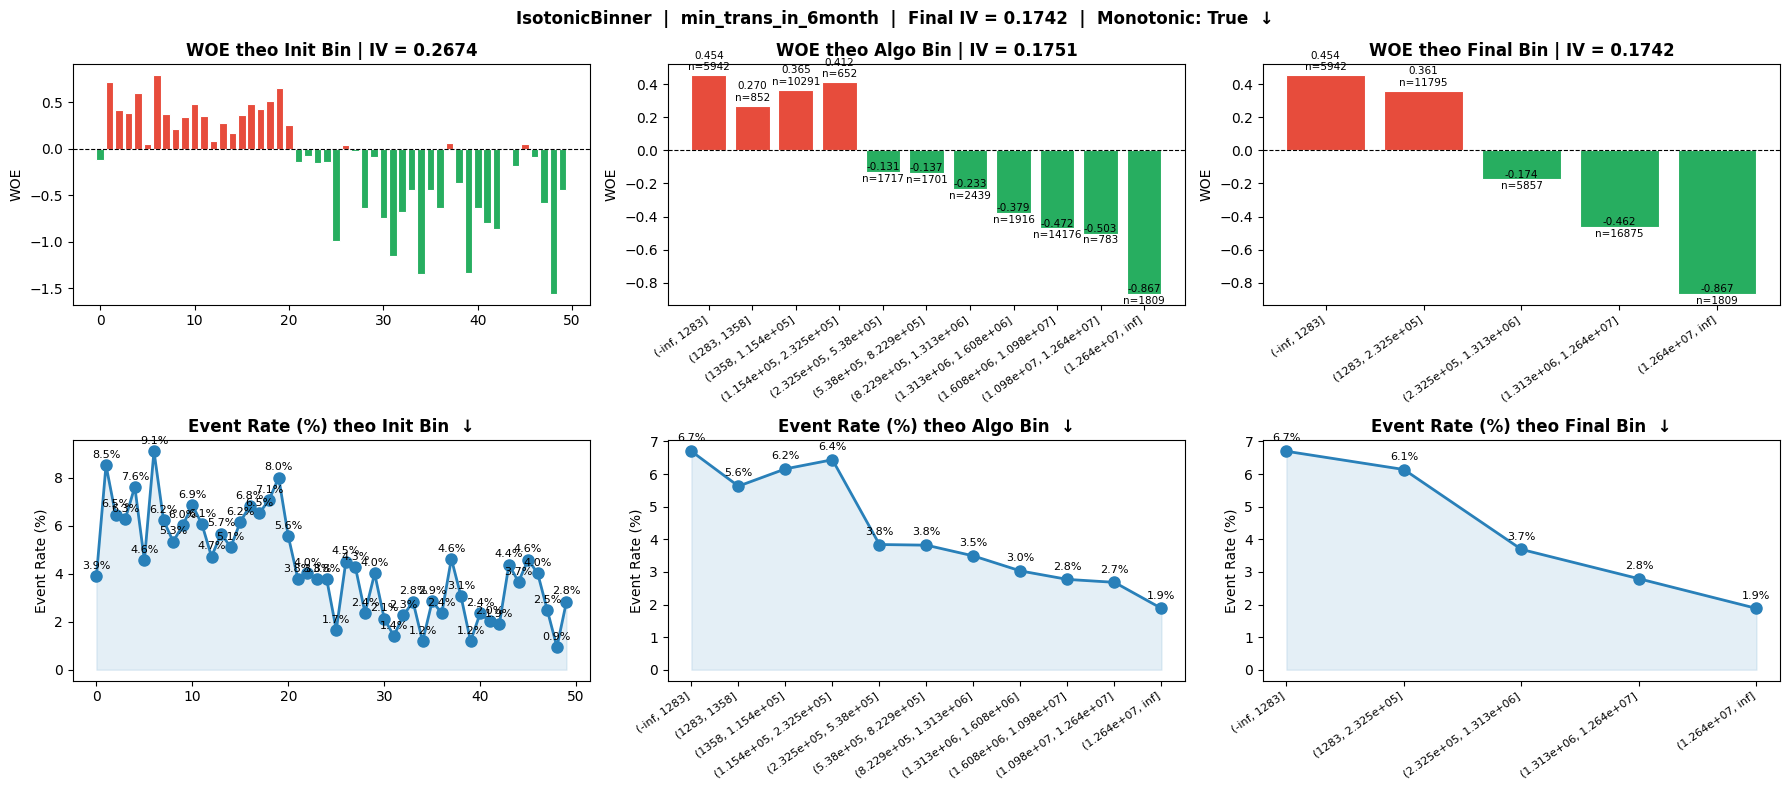

ChiMerge


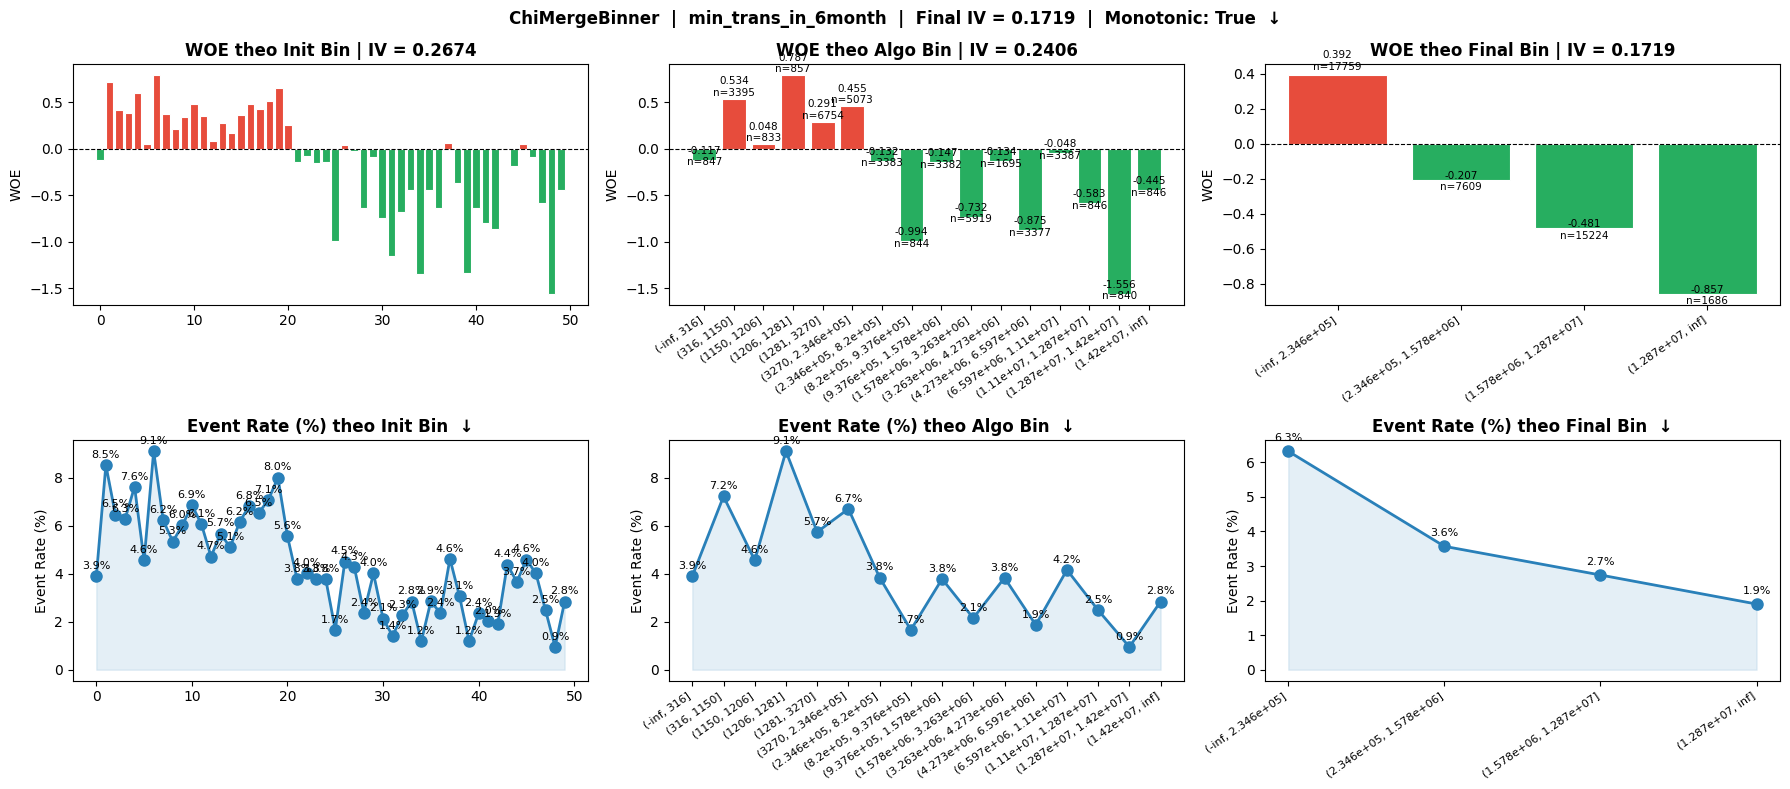

DecisionTree


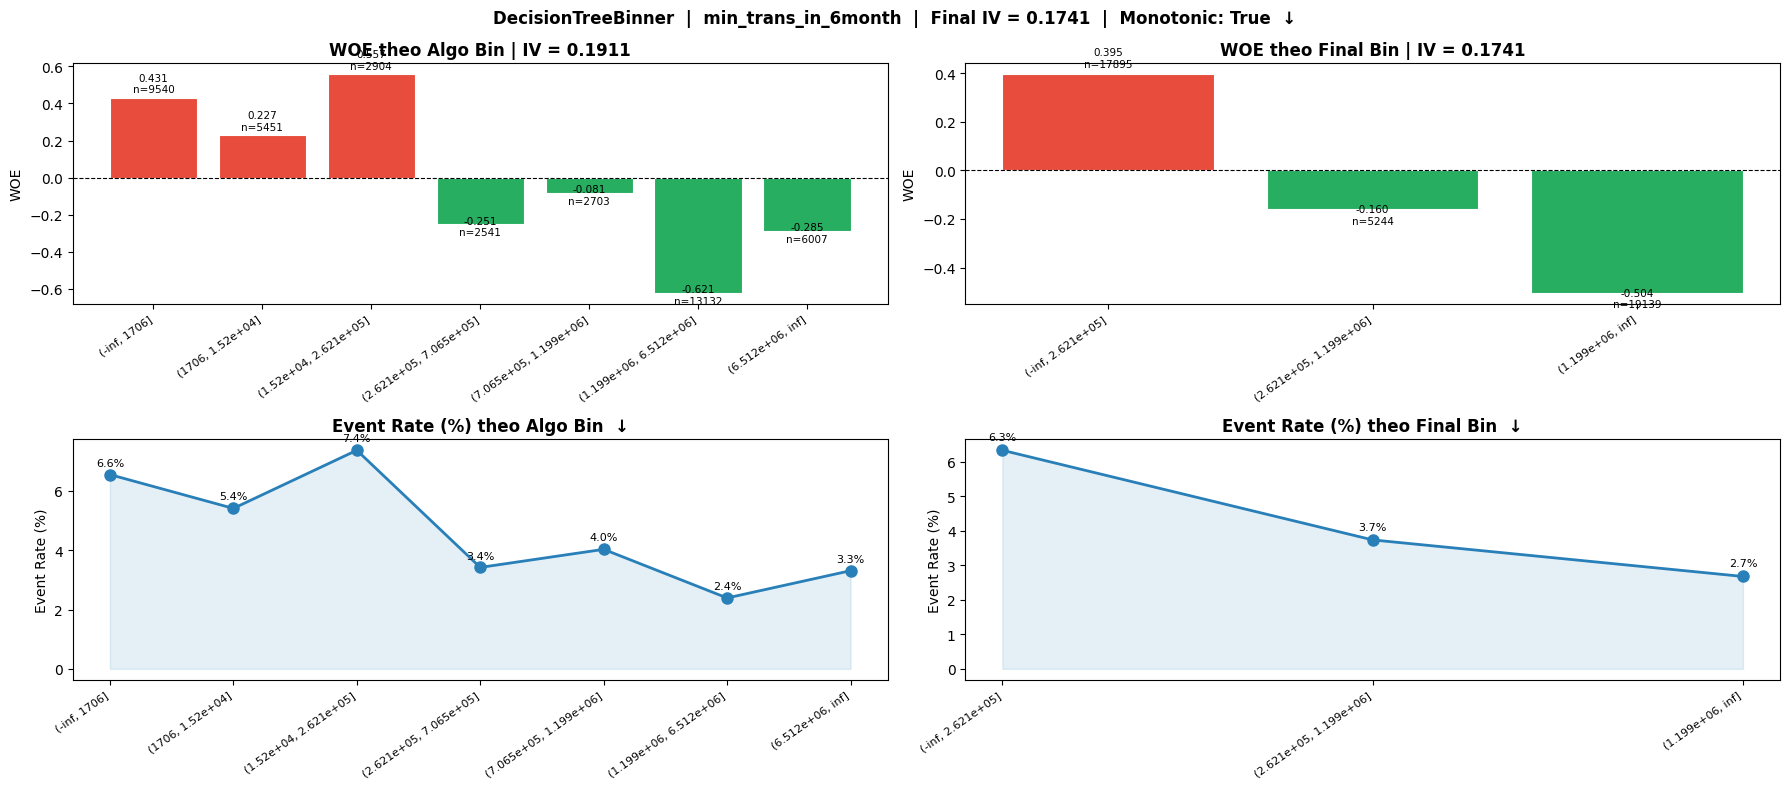

MDLP


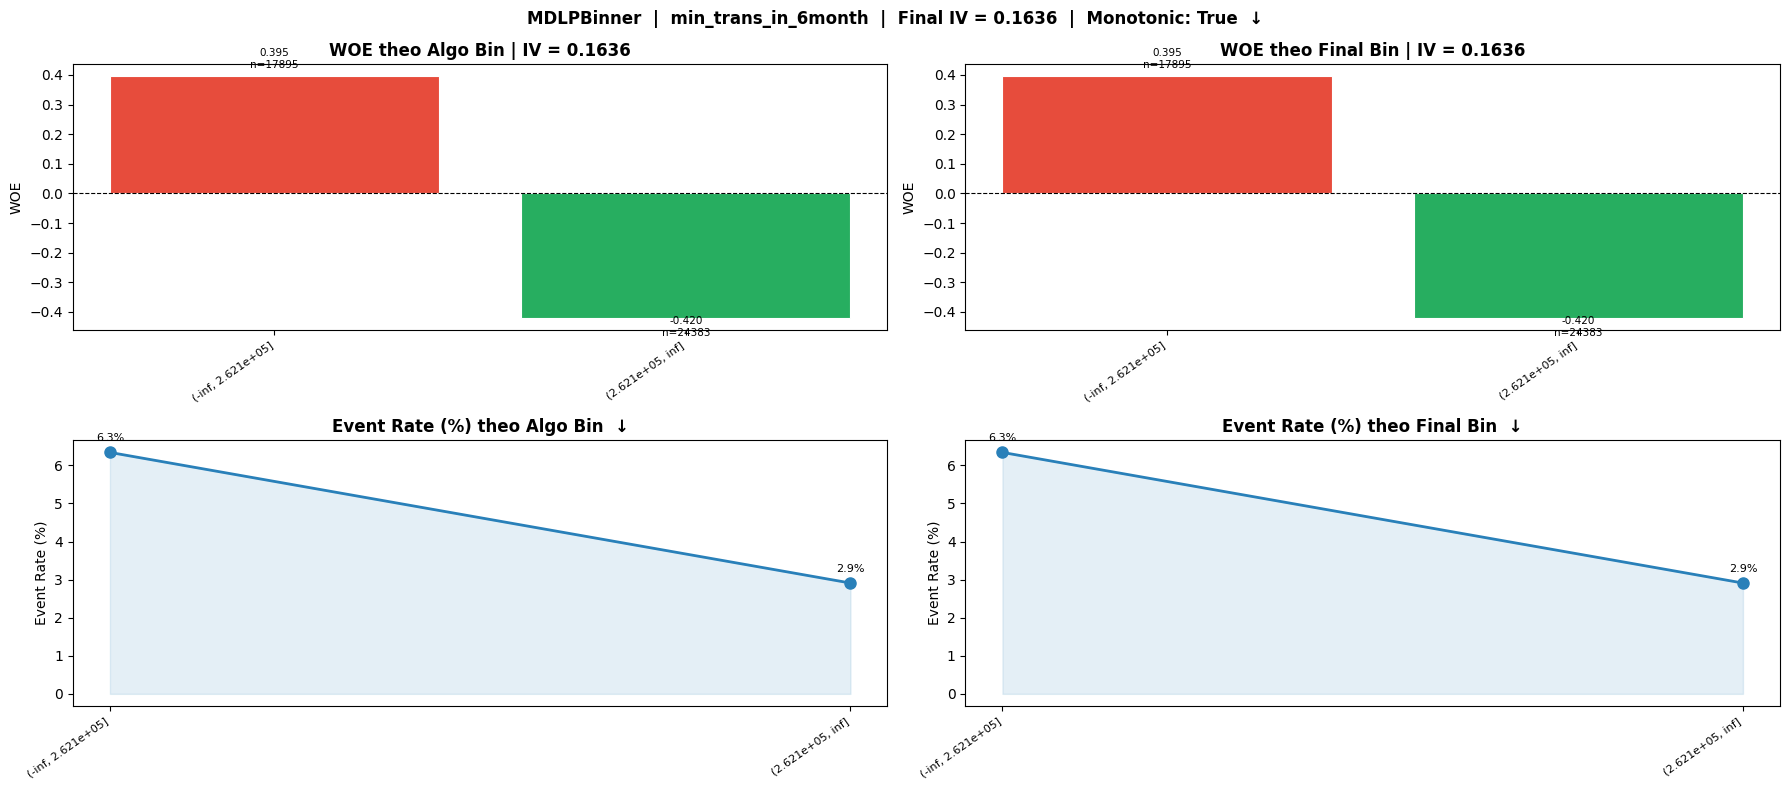

In [9]:
for m in methods:
    print(m)
    _ = methods[m].plot()
    plt.show()


In [10]:
methods

{'QuantileMonotonic': QuantileMonotonicBinner(n_init_bins=50),
 'Isotonic': IsotonicBinner(n_init_bins=50),
 'ChiMerge': ChiMergeBinner(),
 'DecisionTree': DecisionTreeBinner(max_depth=3),
 'MDLP': MDLPBinner()}

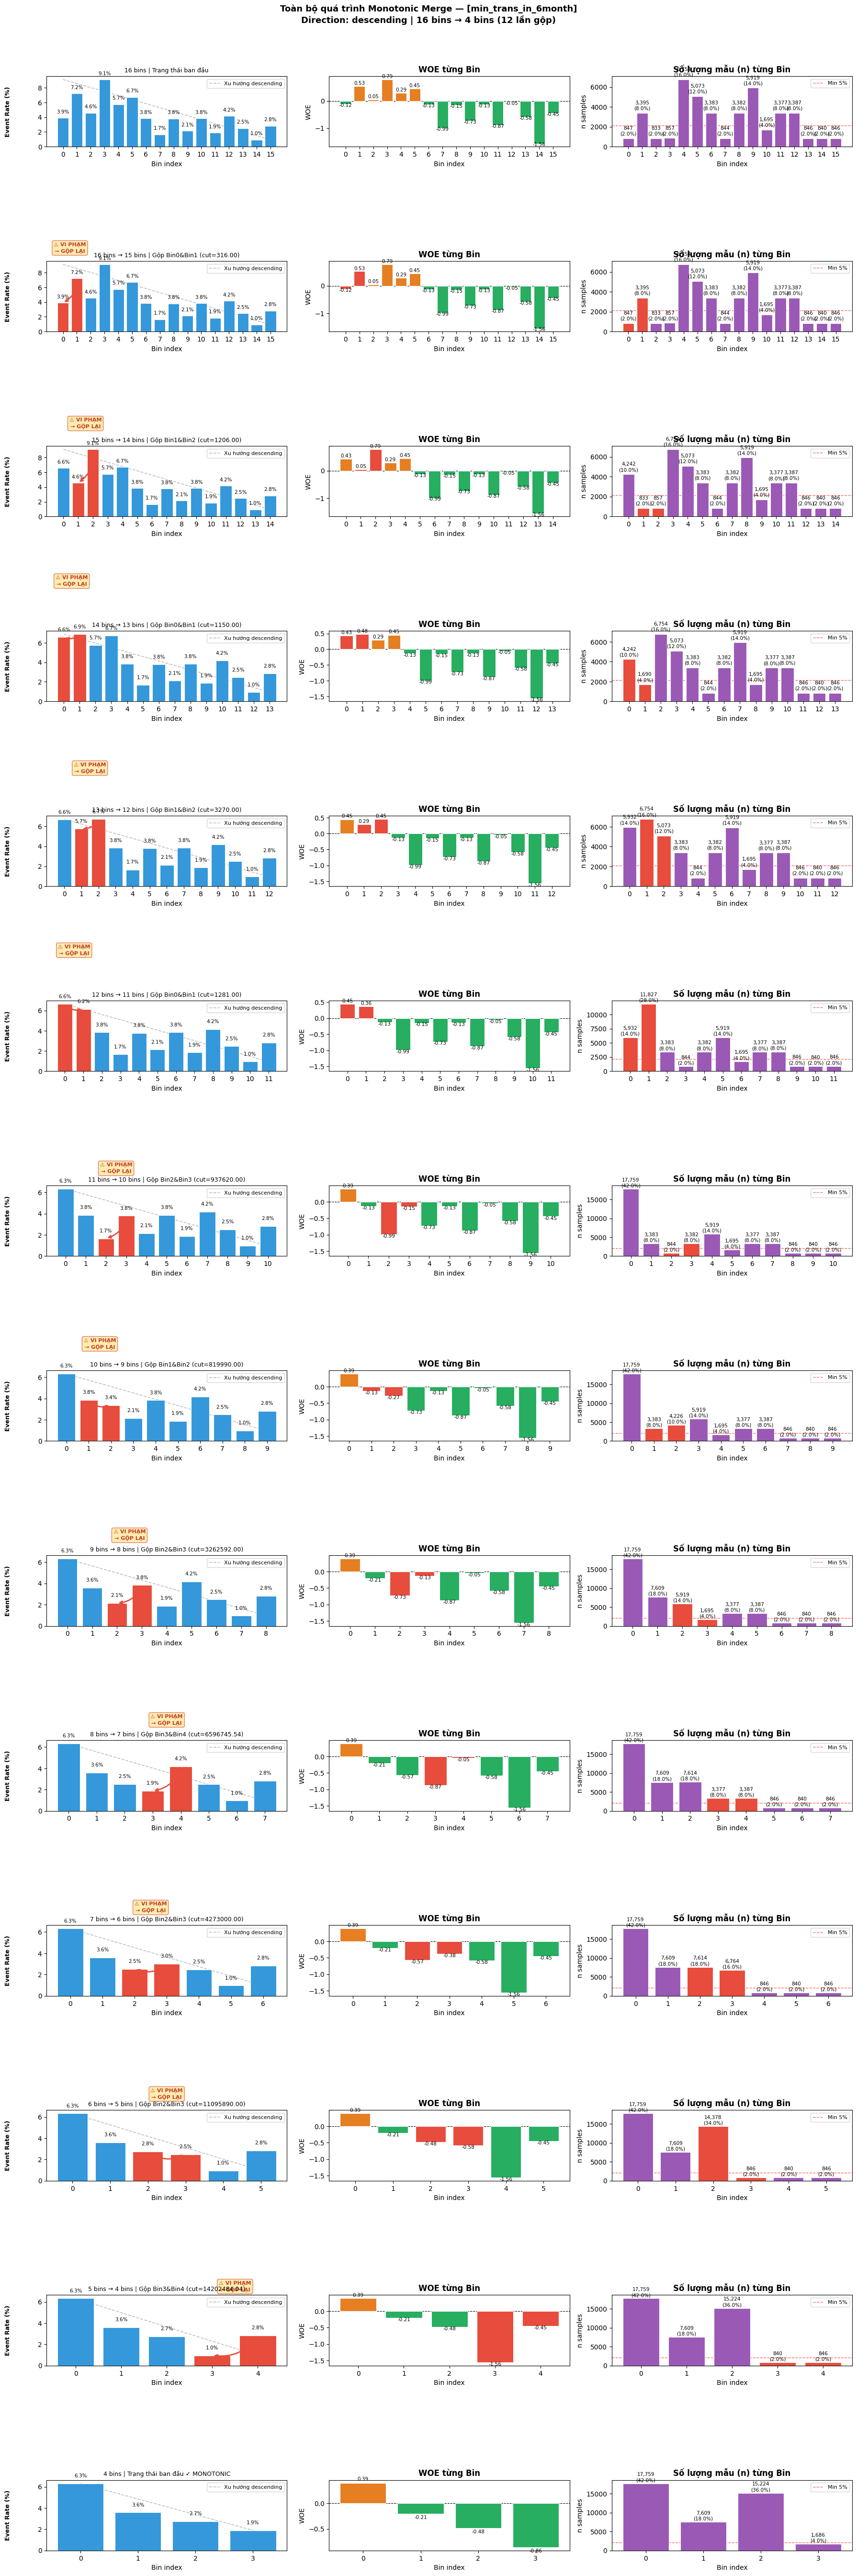

In [11]:
_ = methods['ChiMerge'].trace_.plot_steps()

### Xuất report HTML so sánh nhiều feature (20 tab)

Chạy `generate_compare_report` với danh sách feature (vd 20 cột) để tạo file HTML: mỗi tab một feature, mỗi tab có bảng so sánh, plot Init/Algo/Final (collapse theo thuật toán), plot Merge Steps (collapse). Nếu truyền thêm `df_valid`, report có thêm section Train vs Valid (final_woe + PSI).

In [12]:
# Ví dụ: danh sách 20 feature (số), bỏ target và cột id/date
# feature_cols = [c for c in df.columns if c != "FlagTarget_B4+@9M" and c not in ["customer_code", "cutoff_date", "CUTOFF_MONTH_WID", "province_code_latest"]]
# feature_cols = feature_cols[:20]  # lấy 20 cột đầu

# Chỉ 1 dataset (fit + report)
# from binning_process.report import generate_compare_report
# generate_compare_report(
#     df_train=df,
#     target_col="FlagTarget_B4+@9M",
#     feature_cols=feature_cols,
#     output_path="compare_report.html",
#     max_bins=6,
#     n_init_bins=20,
#     verbose=False,
# )

# Có train + valid (fit trên train, so sánh final_woe và PSI)
# generate_compare_report(
#     df_train=df_train,
#     df_valid=df_valid,
#     target_col="FlagTarget_B4+@9M",
#     feature_cols=feature_cols,
#     output_path="compare_report.html",
#     verbose=False,
# )

In [13]:
data.columns

Index(['FlagTarget_B4+@9M', 'customer_code', 'cutoff_date', 'CUTOFF_MONTH_WID',
       'min_trans_in_3month', 'min_trans_in_6month', 'ltv_max_closedloandtl',
       'collateral_amt_latest', 'n_paidontime_in_3month', 'dpd_mean_in_9month',
       'province_code_latest'],
      dtype='str')

In [14]:
from binning_process.report import generate_compare_report

# # Chỉ train
# generate_compare_report(
#     df_train=data,
#     target_col="FlagTarget_B4+@9M",
#     feature_cols=['min_trans_in_3month', 'min_trans_in_6month', 'ltv_max_closedloandtl',
#        'collateral_amt_latest', 'n_paidontime_in_3month', 'dpd_mean_in_9month'],
#     output_path="compare_report.html",
#     verbose=False,
# )

In [15]:
valid = pd.read_csv(r"D:\Data\f88_bscore_v4\data\Data_Sets_15\20251030_Test_Data.csv")

In [16]:
# Chỉ train
generate_compare_report(
    df_train=data,
    df_valid=valid,
    target_col="FlagTarget_B4+@9M",
    feature_cols=['min_trans_in_3month', 'min_trans_in_6month', 'ltv_max_closedloandtl',
       'collateral_amt_latest', 'n_paidontime_in_3month', 'dpd_mean_in_9month'],
    output_path="compare_report_with_validation.html",
    verbose=False,
)